### Necessary Imports

In [1]:
from astropy.table import Table
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import os
import pathlib
import pandas as pd
import polars as pl

#### Now we'll use the stored rcparams.txt file to format our figure

In [2]:
os.chdir(pathlib.Path.cwd())
def set_rcparams():
    tab = Table.read('rcparams.txt', format='csv')
    for i in range(len(tab)):
        try:
            plt.rcParams[tab['key'][i]] = float(tab['val'][i])
        except ValueError:
            plt.rcParams[tab['key'][i]] = str(tab['val'][i])
    return
set_rcparams()

### First we need to read in all the Gaia information, particularly all the DR2 and DR3 IDs

In [3]:
gaiaids = pl.read_parquet('allgaiadata.parq').to_pandas()
gidssmol = gaiaids[['asas_sn_id', 'gaia_id']]
del gaiaids

### Now let's read in all of our CNN predicted periods

In [4]:
allpred = pd.read_csv('0fullpred.csv', header=None, names=['asas_sn_id', 'period', 'sigma'])
predcitionsandgaia = pd.merge(gidssmol, allpred, on='asas_sn_id', how='inner').drop_duplicates(subset=['asas_sn_id'])
del allpred

### Now we are going to use the gaia-kepler fun DR2 1 arcsecond crossmatch list to get all the KIC IDs for the stars we've inferred a period for

In [ ]:
idmatch = Table.read('files/kepler_dr2_1arcsec.fits', format='fits').to_pandas()
idmatch = idmatch.drop_duplicates(subset=['kepid'])
idmatcher = idmatch[['kepid', 'source_id']]
idmatcher = idmatcher.rename(columns={'kepid':'KIC', 'source_id':'gaia_id'})
del idmatch

### Let's finally merge that all together into a single pd.DataFrame titled 'gaiatotic'

In [7]:
gaiatotic = pd.merge(idmatcher, predcitionsandgaia, on='gaia_id', how='inner')
del predcitionsandgaia, idmatcher

### Now let us load in all of the Santos data. There are two papers of data that we need to combine

In [52]:
santos1 = Table.read('files/crossmatch/santos1.txt', format="ascii.cds").to_pandas()
santos2 = Table.read('files/crossmatch/santos2.txt', format="ascii.cds").to_pandas()
santostot = pd.concat([santos1, santos2])

del santos1, santos2

In [61]:
santosmatch = pd.merge(santostot, gaiatotic, on='KIC', how='inner')
santosmatch['frac_err'] =  santosmatch['sigma']/santosmatch['period']

# Now let's also calculate the percentage difference between our prediction (labeled period) and the Santos periods (labeled Prot)
santosmatch['diff'] = np.abs((santosmatch['period']-santosmatch['Prot'])) / santosmatch['Prot']

### Now that we have all our stars crossmatched with the Santos catalog, let us proceed to bin the data in sigma and fractional uncertainty space so that we can evaluate our recovery cumulutive distribution function 

In [70]:
sigmas = np.arange(start=1.0, stop=17, step=0.28) #produces 58 bins
frac_uncers = np.arange(start=0.05, stop=1.5, step=0.025) #produces 58 bins

numdetected_sig, fracdetected_sig, percenttoten_sig, frac_numdet, frac_fracdet, frac_percten,  = [], [], [], [], [], []

In [71]:
def normalize(data): # This function normalizes our CDFs so that when they are plotted the y-axis is in units of percentage
    return (data - np.min(data)) / (np.max(data) - np.min(data)) * 100

def calc_in_bins(bins, sig_or_frac, number_detected, fraction_detected, percentage_detected):
    """ Calculate the CDFs in either sigma or fractional uncertainty space for matched predictions to those from Santos et al. 
    Args:
        bins (list): a list of the bins within which to calculate the CDFs
        sig_or_frac (boolean): if set to True, we evaluate in sigma-space. If set to False we evaluarte in fractional uncertainty-space
        number_detected (list): an empty list, where the number detected in each bin is stored
        fraction_detected (list): an empty list, where the fraction detected in each bin is stored
        percentage_detected (list): an empty list, where the percentage to within 10% detected in each bin is stored

    Returns:
        None

    """
    temp = []
    for uncertainty in bins:
        if(sig_or_frac==True):
            detected = santosmatch[santosmatch['sigma'] <= uncertainty]
        else:
            detected = santosmatch[santosmatch['frac_err'] <= uncertainty]

        fracdetect = len(detected) / len(santosmatch)
        good = detected[detected['diff']<=0.1]
        try:
            percentrightten = (len(good)/len(detected)) * 100
        except:
            percentrightten = 0
        number_detected.append(len(detected))
        fraction_detected.append(fracdetect)
        percentage_detected.append(percentrightten)

In [72]:
calc_in_bins(sigmas, True, numdetected_sig, fracdetected_sig, percenttoten_sig)
fracdetected_sig_final = normalize(fracdetected_sig)
calc_in_bins(frac_uncers, False, frac_numdet, frac_fracdet, frac_percten)
fracdetected_fracerr_final = normalize(frac_fracdet)

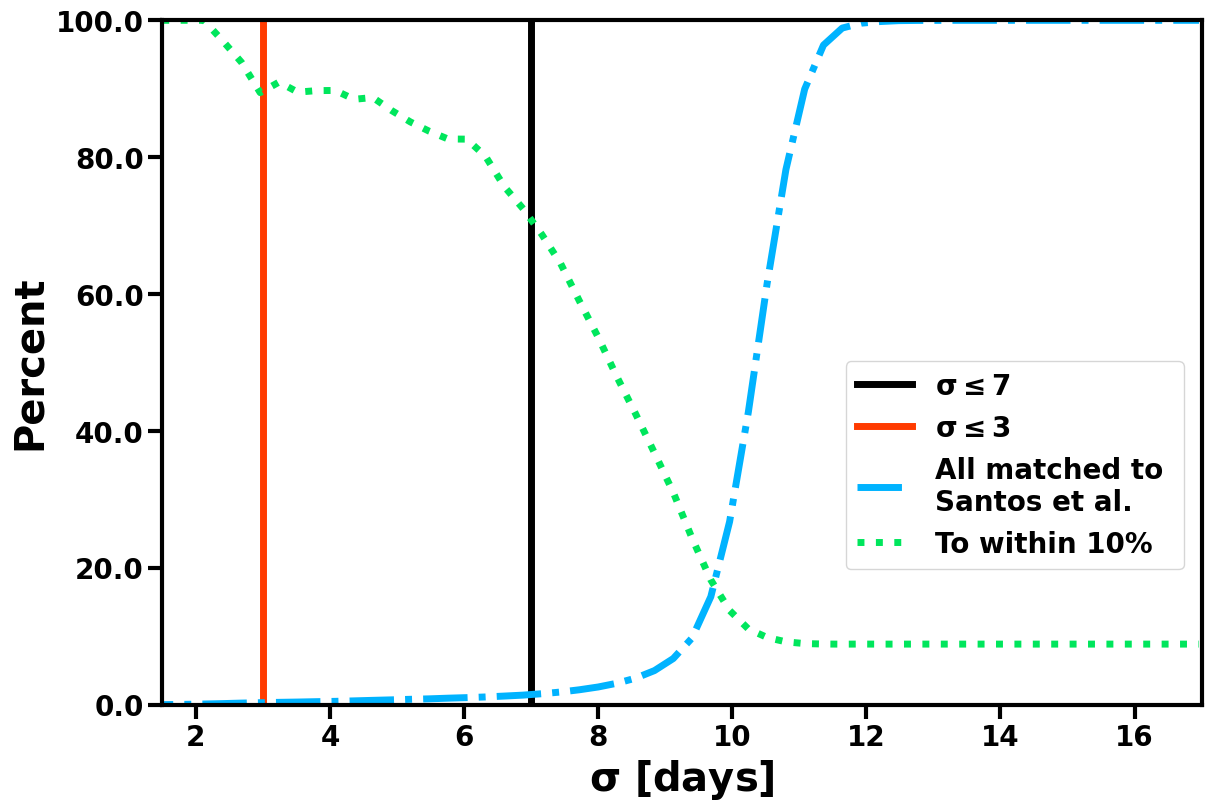

In [75]:
fig, ax = plt.subplots(figsize=(12, 8), layout='constrained')
ax.set(ylim=(0, 100), xlim=(1.5, 17))

formatter = ticker.FormatStrFormatter('%.0')
ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

ax.plot([7, 7], [0, 100], c="#000000", linestyle='-', label=r'$\mathbf{\sigma\leq}$7', linewidth=5)
ax.plot([3, 3], [0, 100], c='#ff3b00', linestyle='-', label=r'$\mathbf{\sigma\leq}$3', linewidth=5)

ax.plot(sigmas, fracdetected_sig_final, c='#00b3ff', linestyle='-.', label='All matched to \nSantos et al.', linewidth=5)
ax.plot(sigmas, percenttoten_sig, c='#00e65c', linestyle=':', label='To within 10%', linewidth=5)

yticksl = ax.get_yticks()
ax.set_yticks(ticks = yticksl, labels=yticksl, weight='bold')
ax.set_xticks(ticks = [2, 4, 6, 8, 10, 12, 14, 16], labels=[2, 4, 6, 8, 10, 12, 14, 16], weight='bold')

ax.set_xlabel(r'$\mathbf{\sigma}$ [days]')
ax.set_ylabel('Percent')
ax.legend(prop={'weight': 'bold'}, bbox_to_anchor=(0.82, 0.35), loc='center')

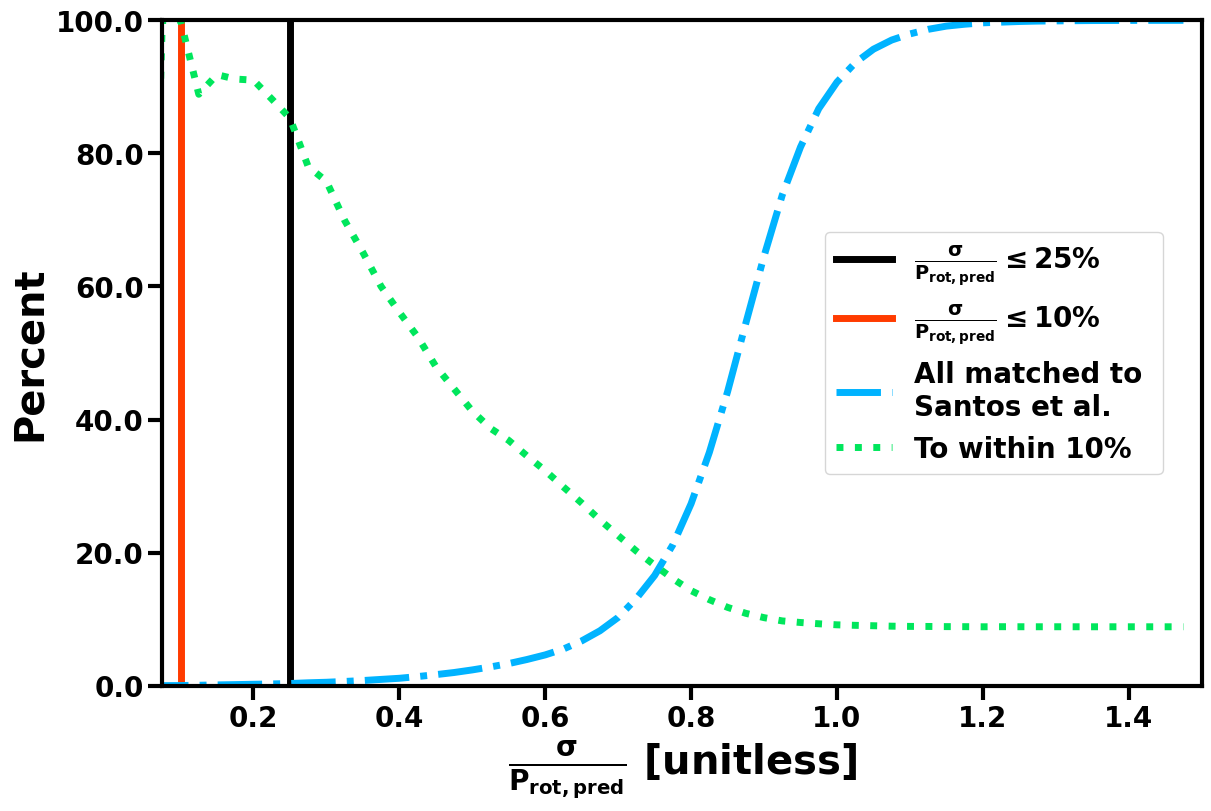

In [76]:
fig, ax = plt.subplots(figsize=(12, 8), layout='constrained')
ax.set(ylim=(0, 100), xlim=(0.075, 1.5))

formatter = ticker.FormatStrFormatter('%.4f')
ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

ax.plot([0.25, 0.25], [0, 100], c="#000000", linestyle='-', label=r'$\mathbf{\frac{\sigma}{P_{rot, pred}} \leq 25\%}$', linewidth=5)
ax.plot([0.1, 0.1], [0, 100], c='#ff3b00', linestyle='-',label=r'$\mathbf{\frac{\sigma}{P_{rot, pred}} \leq 10\%}$', linewidth=5)

ax.plot(frac_uncers, fracdetected_fracerr_final, c='#00b3ff', linestyle='-.', label='All matched to \nSantos et al.', linewidth=5)
ax.plot(frac_uncers, frac_percten, c='#00e65c', linestyle=':', label='To within 10%', linewidth=5)

yticksl = ax.get_yticks()
ax.set_yticks(ticks = yticksl, labels=yticksl, weight='bold')
ax.set_xticks(ticks = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4], labels=[0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4], weight='bold')

ax.set_xlabel(r'$\mathbf{\frac{\sigma}{P_{rot, pred}}}$ [unitless]')
ax.set_ylabel('Percent')
ax.legend(prop={'weight': 'bold'}, bbox_to_anchor=(0.8, 0.5), loc='center')